In [2]:
import tensorflow as tf, keras
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.15.1


## 1. Imports and Configuration

In [3]:
print("[Bloc 1] Imports et configuration : demarrage...")

import hashlib, random, time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v3 as iio          # required by the assignment (image loading/inspection)
import tensorflow as tf
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score)

# Fixed seed: makes randomness (split, shuffle, weight init) reproducible,
# so different architectures can be compared fairly.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Project paths. Code runs inside the Docker container, where the repo is
# mounted at /workspace (see docker-compose.yml).
# ROOT = Path("/workspace")
ROOT = Path("")
RAW = ROOT / "data_raw"      # raw images from TouNum, one sub-folder per category (read only, never modified)
DATA = ROOT / "data"         # derived files only (image index cache data/index.csv), safe to delete
RESULTS = ROOT / "results"   # trained models (.keras) + results CSV
LOGS = RESULTS / "logs"      # TensorBoard logs, one subfolder per architecture
RESULTS.mkdir(exist_ok=True)
LOGS.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)   # size expected by MobileNetV2 (transfer learning)
BATCH = 32

print("[Bloc 1] OK")

[Bloc 1] Imports et configuration : demarrage...
[Bloc 1] OK


## 2. The Data: one category per folder

TouNum's images arrive as one folder per category in `data_raw/` (`Photo`, `Painting`,
`Schematics`, `Sketch`, `Text`). The model only answers *photo / not photo*, but we **keep the
category of every image** in a table (a Pandas DataFrame, one row per image) instead of merging
the folders into two. That table is what lets us:

- split train/val/test **per category**, so every category is represented in the same
  proportion in each part;
- train progressively, from the easy categories (text, schematics) to the hard one (realistic paintings);
- after training, see **which** kind of document is mistaken for a photo.

Nothing is copied or moved: `data_raw/` is only read. The only place where a folder becomes a
binary label is the `CATEGORY_TO_LABEL` dictionary below.

In [4]:
print("[Bloc 2a] Category -> label mapping : demarrage...")

# THE single place where a data_raw/ folder becomes a binary label (1 = photo, 0 = not a photo).
# A folder that is not listed here is ignored, e.g. data_raw/Dataset/ (noisy images, deliverable 2).
CATEGORY_TO_LABEL = {
    "Photo":      1,
    "Painting":   0,
    "Schematics": 0,
    "Sketch":     0,
    "Text":       0,
}
class_names = ["autre", "photo"]   # class_names[label] -> readable name

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
MIN_SIDE = 32   # px. Smaller "images" are web spacers/icons (e.g. 2x2 black squares), not documents

print("[Bloc 2a] OK")

[Bloc 2a] Category -> label mapping : demarrage...
[Bloc 2a] OK


### 2.1 Image index and quality check

Every image is opened once **with the same TensorFlow decoder the training pipeline uses**, so a
file that passes this check cannot crash training later. For each image we record its size, its
colour mode and a fingerprint of its content (MD5 hash, used to find exact duplicates).
Scanning ~40,000 images takes a few minutes, so the result is cached in `data/index.csv`
(rerun with `force=True` if `data_raw/` changes).

In [5]:
print("[Bloc 2b] Image index : demarrage...")

def inspect_image(path):
    # Read one file and return what the quality checks need.
    raw = path.read_bytes()
    info = {"md5": hashlib.md5(raw).hexdigest(), "mode": None,
            "width": None, "height": None, "readable": False}
    try:
        info["mode"] = iio.immeta(path).get("mode")   # L (grey), RGB, RGBA, P (palette), CMYK
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)   # same decoder as training
        info["height"], info["width"] = int(img.shape[0]), int(img.shape[1])
        info["readable"] = True
    except Exception:
        pass   # empty, truncated, or a format TensorFlow cannot decode
    return info

def build_index(force=False):
    # One row per image file of data_raw/, whatever the folder. The mapping is applied afterwards,
    # so changing CATEGORY_TO_LABEL never requires a rescan.
    cache = DATA / "index.csv"
    if cache.exists() and not force:
        print(f"  index lu depuis {cache}")
        return pd.read_csv(cache)
    rows = []
    for folder in sorted(p for p in RAW.iterdir() if p.is_dir()):
        files = sorted(f for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS)
        print(f"  {folder.name}/ : {len(files)} fichiers, inspection...")
        with ThreadPoolExecutor() as pool:   # several files decoded in parallel (I/O + TF release the GIL)
            infos = list(pool.map(inspect_image, files))
        rows += [{"path": f.as_posix(), "category": folder.name, **i} for f, i in zip(files, infos)]
    index = pd.DataFrame(rows)
    DATA.mkdir(exist_ok=True)
    index.to_csv(cache, index=False)
    return index

index = build_index()
index["label"] = index["category"].map(CATEGORY_TO_LABEL)   # NaN for folders not in the mapping
print("  dossiers ignores (absents du mapping) :", sorted(index.loc[index.label.isna(), "category"].unique()))
index = index[index.label.notna()].astype({"label": int})
print(f"  {len(index)} images indexees")

print("[Bloc 2b] OK")

[Bloc 2b] Image index : demarrage...
  index lu depuis data/index.csv
  dossiers ignores (absents du mapping) : ['Dataset']
  39816 images indexees
[Bloc 2b] OK


In [6]:
print("[Bloc 2c] Quality check : demarrage...")

index["too_small"] = index[["width", "height"]].min(axis=1) < MIN_SIDE
index["duplicate"] = index.duplicated("md5", keep="first")   # later copies of an identical file

quality = index.groupby("category").agg(
    images=("path", "size"),
    illisibles=("readable", lambda s: (~s).sum()),
    trop_petites=("too_small", "sum"),
    doublons_exacts=("duplicate", "sum"),
    largeur_mediane=("width", "median"),
    hauteur_mediane=("height", "median"),
)
modes = pd.crosstab(index["category"], index["mode"].fillna("?"))   # colour modes per category
display(quality.join(modes))

# An identical file under two different categories would be a labelling conflict
per_md5 = index.groupby("md5")["category"].nunique()
print("  fichiers identiques presents dans plusieurs categories :", int((per_md5 > 1).sum()))
print("  fichiers illisibles :", index.loc[~index.readable, "path"].tolist())

# Cleaning: removed rows stay visible in `index`, only `df` is used from now on
df = index[index.readable & ~index.too_small & ~index.duplicate].copy()
print(f"  {len(index)} -> {len(df)} images apres nettoyage")

print("[Bloc 2c] OK")

[Bloc 2c] Quality check : demarrage...


,images,illisibles,trop_petites,doublons_exacts,largeur_mediane,hauteur_mediane,?,CMYK,L,P,RGB,RGBA
category,,,,,,,,,,,,
Painting,10000,1,0,4,800.0,800.0,0,1,82,5,9907,5
Photo,9993,0,0,0,640.0,480.0,0,0,25,0,9968,0
Schematics,10000,0,662,691,672.0,462.0,0,0,116,0,9884,0
Sketch,1406,0,0,0,1111.0,1111.0,0,0,868,0,538,0
Text,8417,1,0,0,595.0,842.0,1,0,0,0,8416,0


  fichiers identiques presents dans plusieurs categories : 0
  fichiers illisibles : ['data_raw/Painting/painting_02662.jpg', 'data_raw/Text/text_08417.jpg']
  39816 -> 38718 images apres nettoyage
[Bloc 2c] OK


### 2.2 Train / validation / test split

70 / 15 / 15 %, **stratified on the category** (not only on photo / not photo): each category keeps
the same share in the three parts. The split is done once, on all categories, **before** any data
augmentation or statistic is computed, and exact duplicates were removed beforehand, so the same
image can never be both in train and in test (data leakage). The seed is fixed: the split is
identical on every machine.

In [7]:
print("[Bloc 2d] Split : demarrage...")

train_part, rest = train_test_split(df, test_size=0.30, stratify=df["category"], random_state=SEED)
val_part, test_part = train_test_split(rest, test_size=0.50, stratify=rest["category"], random_state=SEED)
df["split"] = "train"
df.loc[val_part.index, "split"] = "val"
df.loc[test_part.index, "split"] = "test"

# Leakage check: no image content (md5) may appear in two different splits
assert df.groupby("md5")["split"].nunique().max() == 1, "the same image is in two splits"

counts = pd.crosstab(df["category"], df["split"], margins=True, margins_name="total")[["train", "val", "test", "total"]]
display(counts)
display(df.sample(5, random_state=SEED)[["path", "category", "label", "split"]])

print("[Bloc 2d] OK")

[Bloc 2d] Split : demarrage...


split,train,val,test,total
category,,,,
Painting,6996,1499,1500,9995
Photo,6995,1499,1499,9993
Schematics,6236,1336,1336,8908
Sketch,984,211,211,1406
Text,5891,1263,1262,8416
total,27102,5808,5808,38718


,path,category,label,split
36950,data_raw/Text/text_05404.jpg,Text,0,train
19070,data_raw/Photo/photo_8928.jpg,Photo,1,train
28760,data_raw/Schematics/schematics_08620.jpg,Schematics,0,train
19241,data_raw/Photo/photo_9099.jpg,Photo,1,val
14333,data_raw/Photo/photo_4188.jpg,Photo,1,val


[Bloc 2d] OK


[Bloc 2e] Distribution + class imbalance : demarrage...


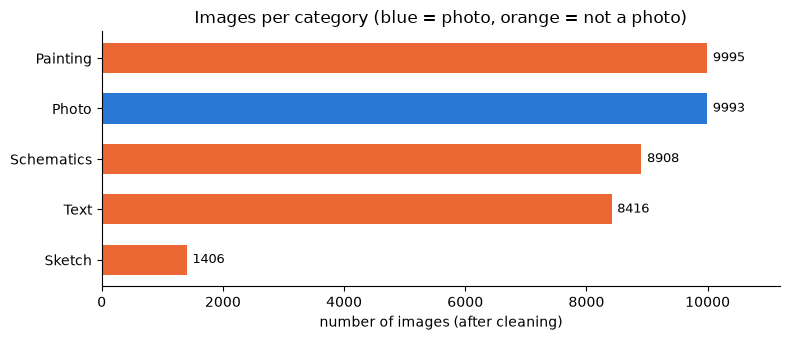

  part de photos (train) : 0.258
  class_weight : {0: 0.674, 1: 1.937}
[Bloc 2e] OK


In [8]:
print("[Bloc 2e] Distribution + class imbalance : demarrage...")

per_cat = df["category"].value_counts().sort_values()
colors = ["#2a78d6" if CATEGORY_TO_LABEL[c] == 1 else "#eb6834" for c in per_cat.index]
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(per_cat.index, per_cat.values, color=colors, height=0.6)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel("number of images (after cleaning)")
ax.set_title("Images per category (blue = photo, orange = not a photo)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, per_cat.max() * 1.12)
plt.tight_layout()
plt.show()

# Photo is ~1 image in 4: without correction, answering "not a photo" everywhere already gives ~74% accuracy.
# Class weights (computed on train only) make each photo error cost as much, in total, as the non-photo errors.
train_labels = df.loc[df.split == "train", "label"]
weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=train_labels)
class_weight = {0: float(weights[0]), 1: float(weights[1])}
print("  part de photos (train) :", round(train_labels.mean(), 3))
print("  class_weight :", {k: round(v, 3) for k, v in class_weight.items()})

print("[Bloc 2e] OK")

## 3. Loading the Images (tf.data)

The DataFrame only holds file paths. `tf.data` reads and decodes the images **on the fly**, batch by
batch, while the model is training: the dataset is never loaded in RAM.

Pixels stay in [0, 255]: the scaling is done **inside each model** (`Rescaling(1/255)` for the CNN,
`preprocess_input` for MobileNetV2). It is a fixed formula, not a statistic computed on the data,
so there is no leakage, and it is saved with the model, so production images get exactly the same
preprocessing.

`make_dataset(split, categories)` can restrict a split to some categories, for the easy-to-hard
progression. The test set always contains every category.

In [9]:
print("[Bloc 3] Loading the images : demarrage...")

AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    # channels=3: grey, RGBA, palette and CMYK images all become RGB
    img.set_shape([None, None, 3])        # decode_image does not tell TF the rank; resize needs it
    img = tf.image.resize(img, IMG_SIZE)  # float32 in [0, 255], aspect ratio not kept
    return img, label

def make_dataset(split, categories=None, shuffle=False):
    part = df[df["split"] == split]
    if categories is not None:
        part = part[part["category"].isin(categories)]
    labels = part["label"].to_numpy("float32").reshape(-1, 1)   # shape (n, 1), expected by binary_crossentropy
    ds = tf.data.Dataset.from_tensor_slices((part["path"].to_numpy(), labels))
    if shuffle:   # shuffling paths (not images) is cheap, so the whole split is shuffled every epoch
        ds = ds.shuffle(len(part), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)   # prefetch: next batch prepared while the current one trains

# None = every category of CATEGORY_TO_LABEL. Easy stage example: ["Photo", "Text", "Schematics"]
TRAIN_CATEGORIES = None
train_ds = make_dataset("train", TRAIN_CATEGORIES, shuffle=True)
val_ds = make_dataset("val", TRAIN_CATEGORIES)
test_ds = make_dataset("test")   # never shuffled: row i of test_df = prediction i
test_df = df[df["split"] == "test"]

for images, labels in train_ds.take(1):
    print("  images :", images.shape, images.dtype, "| min", float(tf.reduce_min(images)), "max", float(tf.reduce_max(images)))
    print("  labels :", labels.shape, labels.dtype, "| photos dans ce batch :", int(tf.reduce_sum(labels)))

print("[Bloc 3] OK")

[Bloc 3] Loading the images : demarrage...
  images : (32, 224, 224, 3) <dtype: 'float32'> | min 0.0 max 255.0
  labels : (32, 1) <dtype: 'float32'> | photos dans ce batch : 10
[Bloc 3] OK


## 4. Visual Inspection of the Data

[Bloc 4] Visual inspection : demarrage...
[Bloc 4] OK


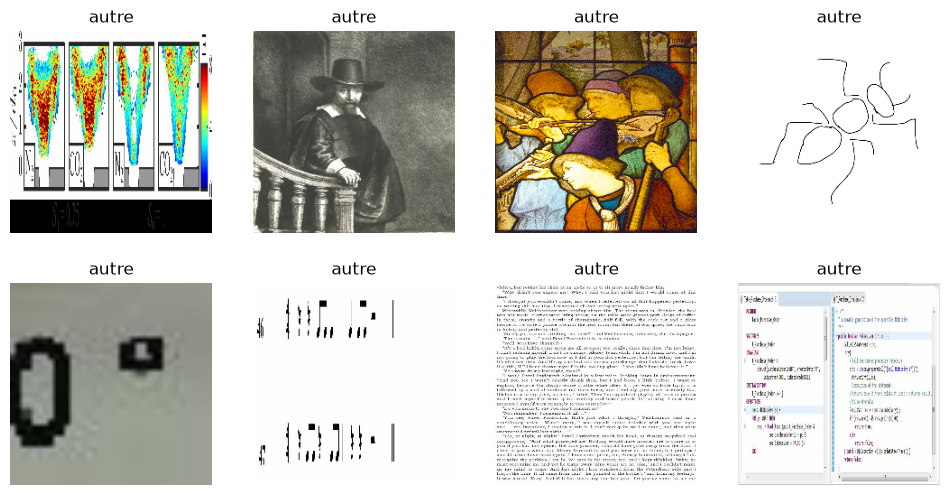

In [10]:
print("[Bloc 4] Visual inspection : demarrage...")

# Always look at the data before training: catches loading bugs, wrong labels,
# or corrupted images early.
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):   # grab a single batch from train_ds
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))   # cast back to displayable uint8 pixels
        plt.title(class_names[int(labels[i][0])])        # label -> human-readable class name
        plt.axis("off")

print("[Bloc 4] OK")

## 5. Data Augmentation (against overfitting)

In [11]:
print("[Bloc 5] Data augmentation : demarrage...")

# Small random transformations applied only during training. The model never sees
# the exact same image twice, which makes it harder to memorize the training set.
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),   # mirror left-right (a flipped photo is still a photo)
    layers.RandomRotation(0.1),        # random rotation up to 10% of a full turn (~36 degrees)
    layers.RandomZoom(0.1),            # random zoom in/out up to 10%
])

print("[Bloc 5] OK")

[Bloc 5] Data augmentation : demarrage...
[Bloc 5] OK


## 6. Building the Architectures to Compare

Three architectures, trained and evaluated the same way, to compare their bias/variance
trade-off: a CNN trained from scratch (baseline), pure transfer learning, and the
hybrid (transfer learning + our own CNN) — the one we keep as the final choice.

### 6.1 CNN from scratch (baseline)

In [12]:
print("[Bloc 6.1] CNN from scratch : definition...")

def build_cnn_from_scratch(name="CNN_from_scratch"):
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augment(inputs)                     # random flip/rotation/zoom, training only
    x = layers.Rescaling(1. / 255)(x)        # pixels 0-255 -> 0-1, this model learns from raw pixels
    x = layers.Conv2D(32, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)              # NEW: regularize after the first conv block
    x = layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)              # NEW: regularize after the second conv block
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)               # NEW: regularize before the final decision
    outputs = layers.Dense(1, activation="sigmoid")(x)   # single probability: photo (1) vs autre (0)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(loss="binary_crossentropy",
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])
    return model

print("[Bloc 6.1] OK")

[Bloc 6.1] CNN from scratch : definition...
[Bloc 6.1] OK


### 6.2 Pure transfer learning (MobileNetV2 + GlobalAveragePooling)

In [13]:
print("[Bloc 6.2] Pure transfer learning : definition...")

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_transfer_model(name="MobileNetV2_transfer"):
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base.trainable = False   # freeze: backprop never updates these weights

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augment(inputs)
    x = preprocess_input(x)          # MobileNetV2's own scaling, not Rescaling(1/255)
    x = base(x, training=False)      # frozen feature extractor -> 7x7x1280 feature grid
    x = layers.GlobalAveragePooling2D()(x)   # average each of the 1280 feature maps into 1 number
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(loss="binary_crossentropy",
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])
    return model

print("[Bloc 6.2] OK")

[Bloc 6.2] Pure transfer learning : definition...
[Bloc 6.2] OK


### 6.3 Hybrid — MobileNetV2 (frozen) + our own CNN — final architecture

In [14]:
print("[Bloc 6.3] Hybrid model : definition...")

def build_hybrid_model(name="Hybrid_MobileNetV2"):
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = augment(inputs)
    x = preprocess_input(x)
    x = base(x, training=False)       # frozen feature extractor -> 7x7x1280 feature grid
    # Our own hand-built CNN on top of the frozen features (1-2 blocks max: the grid is already small)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(loss="binary_crossentropy",
                  optimizer=keras.optimizers.Adam(1e-3),
                  metrics=["accuracy"])
    return model

print("[Bloc 6.3] OK")

[Bloc 6.3] Hybrid model : definition...
[Bloc 6.3] OK


## 7. Training (with Callbacks)

In [15]:
print("[Bloc 7] Training function : definition...")

def train(model, epochs=100):
    callbacks = [
        # Stop early if val_loss stops improving for 3 epochs in a row, and roll back
        # to the weights from the best epoch (not the last one)
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        # Save the model to disk, but only overwrite the file when val_loss improves
        keras.callbacks.ModelCheckpoint(str(RESULTS / f"{model.name}.keras"), save_best_only=True),
        # Write per-epoch metrics for this model to its own log subfolder, for TensorBoard
        keras.callbacks.TensorBoard(log_dir=str(LOGS / model.name)),
    ]
    history = model.fit(train_ds, validation_data=val_ds,
                         epochs=epochs, callbacks=callbacks)
    return model, history

print("[Bloc 7] OK")

[Bloc 7] Training function : definition...
[Bloc 7] OK


In [16]:
print("[Bloc 7b] Lancement de l'entrainement des 3 modeles...")

# Build and train the 3 architectures one by one, keep the model + its history for later
builders = [build_cnn_from_scratch, build_transfer_model, build_hybrid_model]

models, histories = {}, {}
for build_fn in builders:
    model = build_fn()
    print(f"\n=== Training: {model.name} ===\n")
    model, history = train(model)
    models[model.name] = model
    histories[model.name] = history

print("\nEND")
print("[Bloc 7b] OK")

[Bloc 7b] Lancement de l'entrainement des 3 modeles...

=== Training: CNN_from_scratch ===

Epoch 1/100


/usr/local/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


847/847 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.7582 - loss: 0.4614

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1790665529.100194   50356 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


847/847 ━━━━━━━━━━━━━━━━━━━━ 534s 628ms/step - accuracy: 0.7582 - loss: 0.4614 - val_accuracy: 0.7924 - val_loss: 0.3786
Epoch 2/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.7731 - loss: 0.3862

...

847/847 ━━━━━━━━━━━━━━━━━━━━ 428s 505ms/step - accuracy: 0.9817 - loss: 0.0508 - val_accuracy: 0.9787 - val_loss: 0.0616
Epoch 5/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9829 - loss: 0.0463

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1790693411.750434   25009 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


847/847 ━━━━━━━━━━━━━━━━━━━━ 438s 516ms/step - accuracy: 0.9829 - loss: 0.0463 - val_accuracy: 0.9778 - val_loss: 0.0596
Epoch 6/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9845 - loss: 0.0420

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1790693855.479643   28816 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


847/847 ━━━━━━━━━━━━━━━━━━━━ 442s 521ms/step - accuracy: 0.9845 - loss: 0.0420 - val_accuracy: 0.9750 - val_loss: 0.0719

END
[Bloc 7b] OK


## 8. Loss / Accuracy Curves (Train vs Validation)

[Bloc 8] Loss / accuracy curves : demarrage...


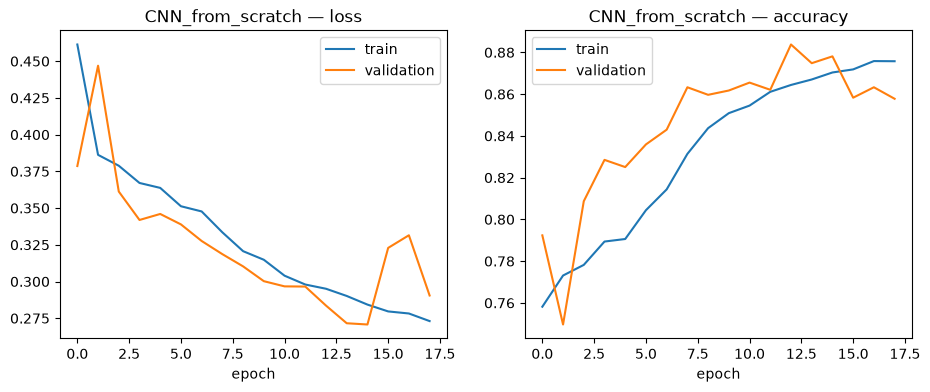

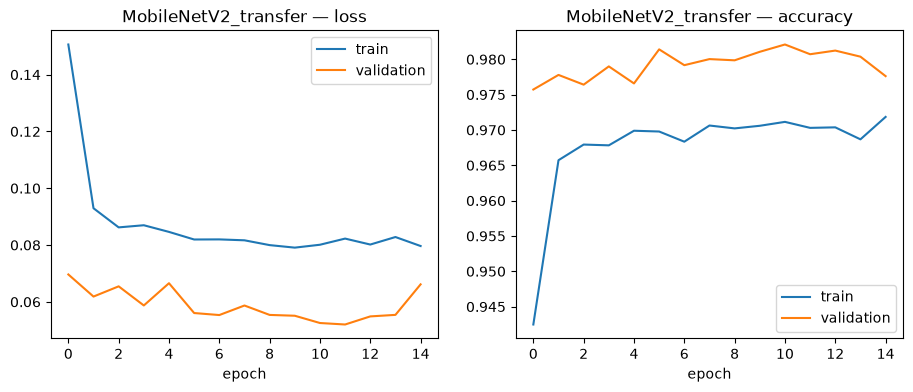

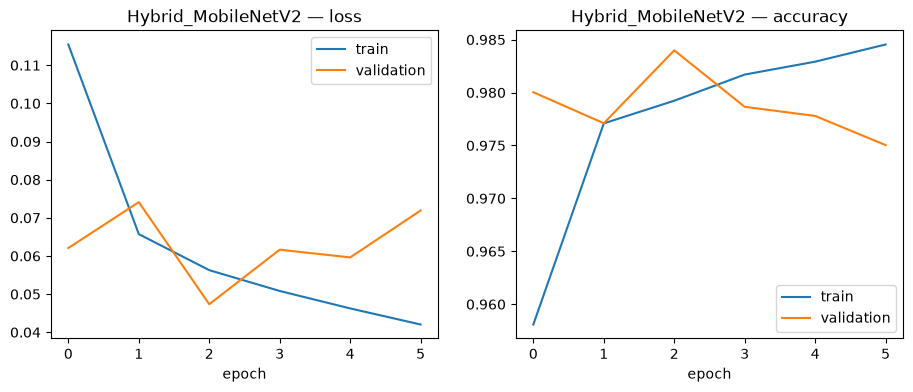

[Bloc 8] OK


In [17]:
print("[Bloc 8] Loss / accuracy curves : demarrage...")

def plot_history(h, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for a, m in zip(ax, ["loss", "accuracy"]):
        a.plot(h.history[m], label="train")
        a.plot(h.history["val_" + m], label="validation")   # h.history stores one list per metric, per epoch
        a.set_title(f"{title} — {m}")
        a.set_xlabel("epoch")
        a.legend()
    plt.show()

# One pair of curves (loss, accuracy) per architecture, required by the assignment
for name, history in histories.items():
    plot_history(history, title=name)

print("[Bloc 8] OK")

## 9. Final Evaluation on the Test Set

In [18]:
print("[Bloc 9] Final evaluation : demarrage...")

import io

def fig_to_tf_image(fig):
    # Convert a matplotlib figure into a TensorBoard-loggable image tensor
    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    plt.close(fig)                    # don't display inline, only send it to TensorBoard
    buf.seek(0)
    img = tf.image.decode_png(buf.getvalue(), channels=4)
    return tf.expand_dims(img, 0)     # tf.summary.image expects a batch dimension

def evaluate_and_log(name, model):
    print(f"  Evaluation de {name}...")
    # True labels for the whole test set, in the same fixed order (shuffle=False)
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).ravel().astype(int)

    t0 = time.time()
    y_prob = model.predict(test_ds, verbose=0).ravel()   # sigmoid probabilities
    ms_per_img = (time.time() - t0) / len(y_true) * 1000  # inference speed, useful for TouNum in prod
    y_pred = (y_prob > 0.5).astype(int)                    # threshold 0.5 -> 0/1 class

    report = classification_report(y_true, y_pred, target_names=class_names)

    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                            display_labels=class_names).plot(ax=ax)
    ax.set_title(name)

    # Send the confusion matrix + report to this model's TensorBoard run instead
    # of showing them inline in the notebook
    eval_writer = tf.summary.create_file_writer(str(LOGS / name / "eval"))
    with eval_writer.as_default():
        tf.summary.image("Confusion Matrix", fig_to_tf_image(fig), step=0)
        tf.summary.text("Classification Report", report, step=0)

    row = {
        "modele": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_photo": precision_score(y_true, y_pred),
        "recall_photo": recall_score(y_true, y_pred),
        "f1_photo": f1_score(y_true, y_pred),
        "ms_par_image": round(ms_per_img, 2),
        "parametres": model.count_params(),
        "taille_Mo": round((RESULTS / f"{name}.keras").stat().st_size / 1e6, 1),
    }
    # Append this model's row to the comparison CSV, replacing any previous row for the same model
    path = RESULTS / "livrable1_resultats.csv"
    df = pd.read_csv(path) if path.exists() else pd.DataFrame()
    df = pd.concat([df[df.get("modele") != name] if len(df) else df,
                    pd.DataFrame([row])], ignore_index=True)
    df.to_csv(path, index=False)
    print(f"  {name}: OK")
    return df

for name, model in models.items():
    results_df = evaluate_and_log(name, model)

print("[Bloc 9] OK")
results_df

[Bloc 9] Final evaluation : demarrage...
  Evaluation de CNN_from_scratch...


  CNN_from_scratch: OK
  Evaluation de MobileNetV2_transfer...
  MobileNetV2_transfer: OK
  Evaluation de Hybrid_MobileNetV2...
  Hybrid_MobileNetV2: OK
[Bloc 9] OK


,modele,accuracy,precision_photo,recall_photo,f1_photo,ms_par_image,parametres,taille_Mo
0,CNN_from_scratch,0.878444,0.728005,0.844563,0.781964,6.28,11963457,143.6
1,MobileNetV2_transfer,0.980200,0.961333,0.961975,0.961654,11.00,2259265,9.7
2,Hybrid_MobileNetV2,0.983815,0.963085,0.974650,0.968833,11.65,3013825,18.7


## 10. Bias/Variance Analysis

**Dataset complet** : 21 979 images train / 4 710 val / 4 710 test (photo + schematics/text/sketch, peintures exclues pour l'instant).

### CNN_from_scratch (baseline)
- Accuracy train 92.7% → 97.8% sur 11 epochs (arrêt par `EarlyStopping`), val 95.3% → 97.4%.
- Loss train finit à 0.063, loss val à 0.081 : écart modéré mais stable, pas de divergence qui s'aggrave.
- Léger surapprentissage, bien contenu grâce au volume de données (22k images) et à la data augmentation.
- **Accuracy test finale : 97.45%**

### MobileNetV2_transfer (transfer learning pur)
- Accuracy train 97.0% → 99.2%, val 98.75% → 99.3% (meilleur epoch : 6, val_loss = 0.0149).
- Courbes train/val quasiment confondues du début à la fin → overfitting quasi nul, comportement attendu (backbone gelé = très peu de paramètres réellement appris).
- **Accuracy test finale : 99.45%**

### Hybrid_MobileNetV2 (architecture retenue)
- Convergence très rapide : val_accuracy déjà à 99.28% dès l'epoch 1.
- Meilleur val_loss à l'epoch 2 (0.016), puis légère remontée (0.019-0.020) → `EarlyStopping` arrête à l'epoch 5 et restaure les poids de l'epoch 2 (`restore_best_weights=True`).
- Léger surapprentissage détecté, mais neutralisé immédiatement par le callback.
- **Accuracy test finale : 99.47%** (meilleur score des 3 modèles)

### Comparaison avec l'essai sur échantillon réduit (300 images/classe)
Sur le petit échantillon de test, ce même modèle hybride montrait un surapprentissage net et **progressif** (val_loss passant de 0.070 à 0.183 sur 5 epochs, accuracy val en baisse après l'epoch 3). Sur le dataset complet, le même modèle converge tout aussi vite mais avec un surapprentissage **beaucoup plus contenu** (val_loss 0.016 → 0.019 seulement). Ça confirme empiriquement, avec des chiffres à l'appui, ce qui est attendu en théorie : à architecture égale, plus de données réduit directement le surapprentissage.

### Conclusion
Aucun signe de sous-apprentissage sur les 3 modèles (tous >97% d'accuracy en train et en val). Le compromis biais/variance est bien maîtrisé grâce à la combinaison volume de données + data augmentation + EarlyStopping. Le modèle **hybride** reste le choix recommandé : meilleure accuracy test, overfitting contenu, et architecture explicable couche par couche (contrairement au transfer learning pur, boîte noire côté MobileNetV2).